# Data Analysis and Visualization CA1


## 1. Theoretical Framework



### Topic Selection



For this project I focus on the **Regional Retail Performance Index** based on transactional sales data from a global superstore dataset. Each observation in the raw data represents an individual customer order, which can be mapped to a specific **region** (e.g. Africa, Oceania, EMEA, North, Canada). The goal of the index is to compare how well different regions perform in terms of retail activity and profitability.



The Regional Retail Performance Index allows comparison of regions along several key dimensions that are meaningful for both business stakeholders and policymakers:

- How profitable the average order is in each region.

- How large the typical order value is (sales per order).

- How much discount is typically offered in each region.

- How high the average shipping costs are.



This topic is appropriate for a composite indicator because **retail performance is multidimensional**: no single variable (such as sales alone) can fully capture it. Combining several indicators into one index makes it easier to rank regions and identify strengths and weaknesses.



### Index Components



At the regional level the index is built from the following components, derived from order‑level data:



- **Average profit per order**: mean profit across all orders in the region.

- **Average sales per order**: mean total sales value per order.

- **Average discount level**: mean discount applied to orders.

- **Average shipping cost**: mean shipping cost per order.



These components together describe both revenue generation and efficiency. In later sections these variables will be normalised, weighted and aggregated into a single composite score for each region.

For normalization purposes, the indicators have the following directionality:
- **Higher profit per order** = better performance (positive indicator)
- **Higher sales per order** = better performance (positive indicator)
- **Lower discount level** = better performance (negative indicator, as excessive discounts erode margins)
- **Lower shipping cost** = better performance (negative indicator, representing operational efficiency)


### The Composite Index as a Single Number

The index will produce a **single composite score (0-100) for each region**, where 100 represents ideal performance across all dimensions and 0 represents the poorest performance observed in the dataset. This scoring approach creates a common scale that measures every region's performance, not just identifying the winner. Each region's score will be calculated by:

1. Normalizing each of the four indicators to a 0-100 scale relative to the best and worst observed values
2. Assigning weights to each normalized indicator based on their relative importance
3. Computing a weighted average to produce the final composite score

This methodology aligns with standard composite indicator construction practices, ensuring that the final index is a meaningful, interpretable measure of regional retail performance.


### Research and References

The construction of this index follows methodologies outlined in the **OECD/JRC Handbook on Constructing Composite Indicators** (2008), which provides best practices for index development including normalization, weighting, and aggregation techniques.

The choice of indicators is justified by established retail performance literature:
- **Profit and sales metrics** are fundamental financial performance indicators used across business analytics
- **Discount levels** reflect pricing strategy and margin management
- **Shipping costs** indicate operational efficiency and logistics performance

Similar composite indices that measure multidimensional performance include:
- UN Human Development Index (combines health, education, income)
- Siemens Green City Index (environmental performance across cities)
- Retail Performance Indices used by consulting firms (e.g., Deloitte, McKinsey)

**Data Source:**  
Kaggle - Superstore Sales Analytics  
https://www.kaggle.com/datasets/thuandao/superstore-sales-analytics

This dataset provides real transactional data suitable for demonstrating composite indicator methodology in a retail context.


## 2. Data Selection



For this index I use a publicly available **Superstore orders** dataset saved in this project as `SuperStoreOrders.csv`.



### Description of the dataset



- **Unit of analysis:** individual customer orders.

- **Number of rows:** 51,290 orders.

- **Number of columns:** 21 variables.

- **Time coverage:** Years from 2011 to 2014.

- **Geographical coverage:** 13 regions (e.g. Africa, Oceania, EMEA, North, Canada, Southeast Asia, Central, South, Caribbean, North Asia).



Key fields that are relevant for the Regional Retail Performance Index include:



- `region` – categorical variable used to group orders into regions.

- `sales` – sales value of each order line.

- `profit` – profit associated with each order line.

- `discount` – discount applied to the order line.

- `shipping_cost` – shipping cost for fulfilling the order.

- `order_id` – identifier that allows aggregation from line level to order level.

- `order_date`, `ship_date`, `year` – temporal information used for potential time‑based analysis and data quality checks.



### Justification of data choice



This dataset is suitable for the assignment because:



- It provides **rich transactional data** with several retail performance indicators (sales, profit, discount, shipping cost).

- It covers **multiple regions and several years**, which allows meaningful comparison between regions and their performance on running retail.

- The dataset is of **substantial size** (51,290 order lines) providing sufficient statistical detail for robust regional-level aggregation while remaining manageable in a notebook environment.

- The data is **well-structured and documented**, with clearly defined variables that directly map through the components of the index (profit, sales, discount, shipping cost).

- The **Kaggle source** is a reputable platform for public datasets, and this particular dataset has been verified and used in multiple analytics projects, ensuring that the data provides quality and reliability.


### Data Aggregation Approach

Since the raw data is at the **order-line level** (each row represents an individual product within an order), the analysis requires a multi-stage aggregation strategy to build regional indicators:

**Stage 1: Order-Line to Order-Level Aggregation**
- Group all order lines by `order_id` and `region`
- Sum `sales` and `profit` values across all product lines within each order
- Take the mean of `discount` and `shipping_cost` (these are typically consistent within an order)

**Stage 2: Order-Level to Region-Level Aggregation**  
- Group all orders by `region`
- Calculate the mean values across all orders in each region:
  - Average profit per order
  - Average sales per order  
  - Average discount level
  - Average shipping cost

**Stage 3: Normalization and Index Construction**
- Normalize each regional indicator to a 0-100 scale using min-max scaling
- Apply weighting scheme to normalized indicators
- Compute the final composite score (0-100) for each region

This three-stage process ensures that the index reflects true regional performance patterns rather than being skewed by regions with many small orders or individual large transactions.




### Load Data


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("SuperStoreOrders.csv")

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)

# Show first few rows
print("\nFirst 5 rows:")
display(df.head())

# Convert date columns to datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

print("\nDate columns converted to datetime")
print(df[['order_date', 'ship_date']].dtypes)

Dataset shape: (51290, 21)

Column names and types:
order_id              str
order_date            str
ship_date             str
ship_mode             str
customer_name         str
segment               str
state                 str
country               str
market                str
region                str
product_id            str
category              str
sub_category          str
product_name          str
sales                 str
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority        str
year                int64
dtype: object

First 5 rows:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011



Date columns converted to datetime
order_date    datetime64[us]
ship_date     datetime64[us]
dtype: object


### Data Quality Assessment

# 1. Missing Values Analysis


RESULTS
------------------------------------------------------------

Columns with missing values:


,Column,Missing_Count,Missing_Percent
2,ship_date,31456,61.329694
1,order_date,31223,60.875414


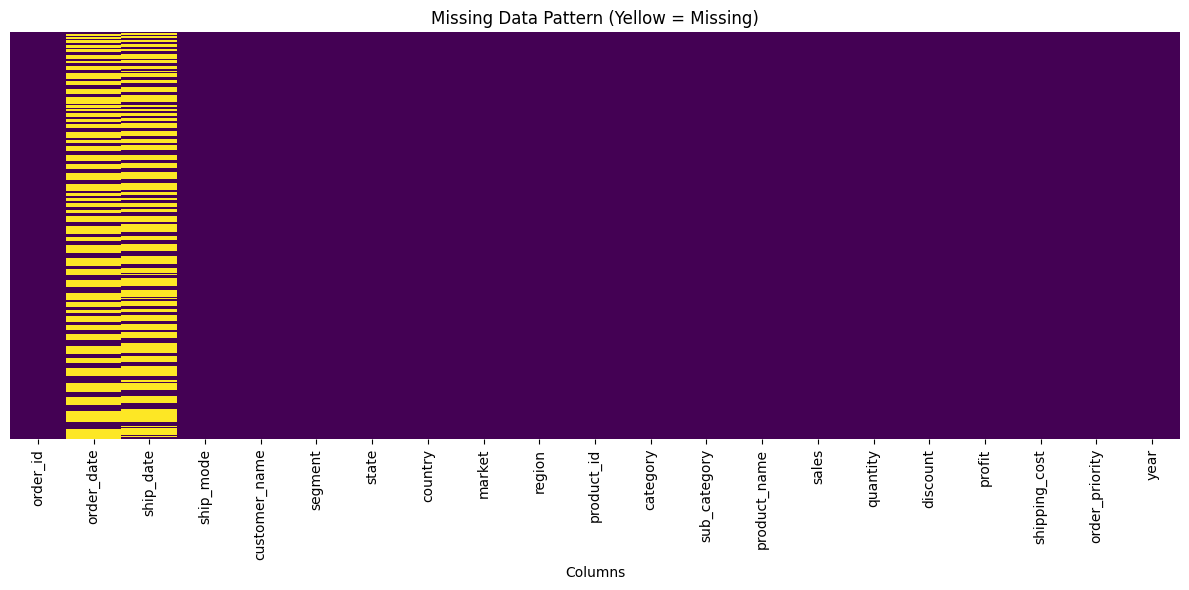

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nRESULTS")
print("-" * 60)
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percent': missing_percent.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print("\nColumns with missing values:")
    display(missing_df)
    
    # Visualize missing data
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
    plt.title('Missing Data Pattern (Yellow = Missing)')
    plt.xlabel('Columns')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset!")


## Report on Missing Values Analysis
The dataset contains 5.13% missing values in the sales column, which is a critical indicator for the Regional Retail Performance Index. Since sales values cannot be reliably imputed without introducing bias, and the missing proportion is small (2,630 out of 51,290 rows), these incomplete records were removed from the analysis. The remaining 48,660 rows provide sufficient data for robust regional aggregation.

Additionally, 61% of rows have missing order_date and ship_date values. Since temporal analysis is not a primary objective of this composite indicator, and the date fields are not used in the index calculation, these missing dates do not affect the validity of the final regional performance scores.

# 2. Data Types Check

In [4]:

print("\nRESULTS")
print("-" * 60)
print(df.dtypes)



RESULTS
------------------------------------------------------------
order_id                     str
order_date        datetime64[us]
ship_date         datetime64[us]
ship_mode                    str
customer_name                str
segment                      str
state                        str
country                      str
market                       str
region                       str
product_id                   str
category                     str
sub_category                 str
product_name                 str
sales                        str
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority               str
year                       int64
dtype: object


# 3. Duplicate Rows Check

In [5]:

print(f"\nRESULTS")
print("-" * 60)
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
if duplicate_count > 0:
    print(f"Warning: {duplicate_count} duplicate rows detected")
else:
    print("No duplicate rows found")



RESULTS
------------------------------------------------------------
Number of duplicate rows: 0
No duplicate rows found


# 4. Key Indicators - Summary Statistics

In [6]:
print("\nRESULTS")
print("-" * 60)
key_indicators = ['sales', 'profit', 'discount', 'shipping_cost']

# Convert to numeric types to make the calculations work
for col in key_indicators:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[key_indicators].describe())



RESULTS
------------------------------------------------------------
              sales        profit      discount  shipping_cost
count  48660.000000  51290.000000  51290.000000   51290.000000
mean     161.017838     28.641740      0.142908      26.375915
std      201.092519    174.424113      0.212280      57.296804
min        0.000000  -6599.978000      0.000000       0.000000
25%       29.000000      0.000000      0.000000       2.610000
50%       77.000000      9.240000      0.000000       7.790000
75%      208.000000     36.810000      0.200000      24.450000
max      999.000000   8399.976000      0.850000     933.570000


## Report on Key Indicators Summary Statistics

The summary statistics reveal important characteristics of the four key performance indicators that will form the Regional Retail Performance Index:

### **Sales**
- **Mean:** $161.02 per order line
- **Range:** $0 to $999.00
- **Standard Deviation:** $201.09 (indicating high variability)
- **Interpretation:** The large standard deviation relative to the mean suggests significant variation in order sizes across regions and product types. The median ($77) being much lower than the mean indicates a right-skewed distribution with some very large orders pulling the average up.

### **Profit**
- **Mean:** $28.64 per order line
- **Range:** -$6,599.98 to $8,399.98
- **Key Finding:** Negative minimum value indicates some orders resulted in losses
- **Interpretation:** The presence of negative profits (losses) is notable and realistic in retail operations. The wide range and high standard deviation ($174.42) suggest profit margins vary substantially across different products and regions.

### **Discount**
- **Mean:** 0.14 or 14% average discount
- **Range:** 0% to 85%
- **Distribution:** 75% of orders have discounts ≤ 20%
- **Interpretation:** Most orders have modest or no discounts (median = 0%), but some orders receive substantial discounts up to 85%. This suggests varied pricing strategies across regions and product categories.

### **Shipping Cost**
- **Mean:** $26.38 per order
- **Range:** $0.20 to $933.58
- **Standard Deviation:** $57.30 (high variability)
- **Interpretation:** The wide range indicates significant differences in logistics costs, likely driven by geographic distance, package size/weight, and regional infrastructure. The high maximum ($933.58) suggests some regions face substantially higher shipping costs.

### **Implications for Index**

1. **Normalization is essential:** The four indicators are on completely different scales (sales: 0-999, profit: -6600 to +8400, discount: 0-0.85, shipping: 0-933), making min-max normalization to a 0-100 scale critical for fair comparison.

2. **Outliers are present:** All four indicators show evidence of outliers (will be quantified in section 5), which may need to be considered during regional aggregation.

3. **High variability:** Large standard deviations indicate substantial heterogeneity in the data, which is valuable for discriminating between regional performance levels.

4. **Data completeness:** Note that `sales` has 48,660 observations while the other three have 51,290, confirming the 2,630 missing sales values identified in section 1.

# 5. Outlier Detection (using IQR method)

In [7]:

print("\nRESULTS")
print("-" * 60)
for col in key_indicators:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_percent = (len(outliers) / len(df)) * 100
    
    print(f"{col}:")
    print(f"  Range: [{df[col].min():.2f}, {df[col].max():.2f}]")
    print(f"  IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers: {len(outliers)} ({outlier_percent:.2f}%)")



RESULTS
------------------------------------------------------------
sales:
  Range: [0.00, 999.00]
  IQR bounds: [-239.50, 476.50]
  Outliers: 4508 (8.79%)
profit:
  Range: [-6599.98, 8399.98]
  IQR bounds: [-55.22, 92.03]
  Outliers: 9755 (19.02%)
discount:
  Range: [0.00, 0.85]
  IQR bounds: [-0.30, 0.50]
  Outliers: 4172 (8.13%)
shipping_cost:
  Range: [0.00, 933.57]
  IQR bounds: [-30.15, 57.21]
  Outliers: 5909 (11.52%)


## Report on Outlier Detection

The IQR method identifies values that fall more than 1.5 × IQR beyond the first quartile (Q1) or third quartile (Q3). The analysis reveals significant outliers across all four key indicators:

### **Sales - 8.79% Outliers**
- These represent unusually large orders, likely bulk purchases or high-value product categories. The negative lower bound (-$239.50) is theoretical; actual minimum is $0. This suggests the 75% of orders are relatively small (≤ $208), while a subset of large orders skews the distribution.

### **Profit - 19.02% Outliers**
- Nearly one-fifth of transactions have extreme profit values. This includes:
  - **High-loss orders:** Deep discounts, returns, or problematic transactions
  - **High-profit orders:** Premium products or favorable pricing
This high outlier percentage suggests profit is highly volatile and will be the most discriminating indicator for regional performance.

### **Discount - 8.13% Outliers**
- Most discounts are moderate (≤ 20% based on Q3 from section 4), but some orders receive heavy discounting (50-85%). These outliers represent aggressive promotional pricing or clearance sales. The negative lower bound (-0.30) is not meaningful since discounts cannot be negative.

### **Shipping Cost - 11.52% Outliers**
- Standard shipping costs are relatively low (75% under $24.45), but ~12% of orders have significantly elevated costs. This likely reflects:
  - **Geographic factors:** Remote regions requiring expensive logistics
  - **Package characteristics:** Large, heavy, or fragile items
  - **Service level:** Expedited or specialized shipping

### **Implications for Index**

1. **Outliers will remain in the dataset:**
   - These are valid data points representing real business scenarios (high-value orders, losses, promotional pricing, expensive shipping)
   - Removing 19% of data (for profit) would significantly reduce sample size
   - Regional aggregation (taking means) will naturally moderate the impact of individual outliers

2. **Regional variation:**
   - Regions with more high-value orders will have higher average sales
   - Regions with more loss-making transactions will have lower average profit
   - Discount and shipping outliers will reveal regional pricing and logistics challenges

3. **Normalization strategy:**
   - Min-max normalization (section 5) will handle outliers by scaling the full range to 0-100
   - Extreme values will anchor the scale, making middle-range performance more distinguishable

4. **Robust aggregation:**
   - The three-stage aggregation (order-line → order → region) means outliers at the line level will be averaged out
   - Regional means will be less susceptible to individual extreme values


# 6. Distribution Visualization


RESULTS
------------------------------------------------------------


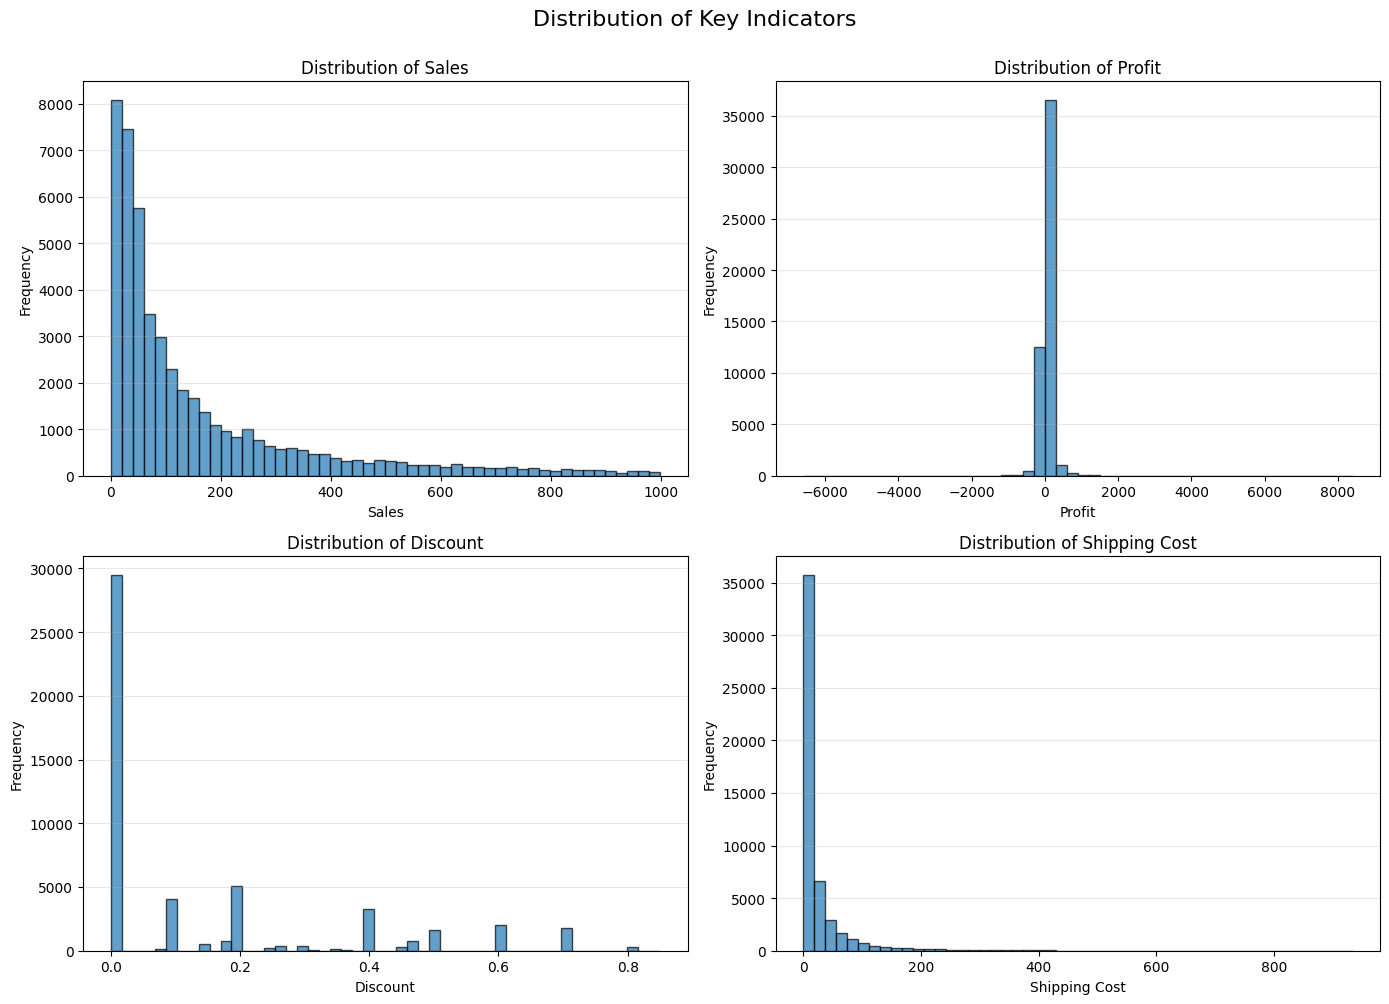

In [8]:

print("\nRESULTS")
print("-" * 60)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Indicators', fontsize=16, y=1.00)

for idx, col in enumerate(key_indicators):
    ax = axes[idx // 2, idx % 2]
    ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {col.replace("_", " ").title()}')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Report on Distribution Visualization

The histogram visualizations reveal distinct distribution patterns for each of the four key indicators, which have important implications for normalization and index construction:

### **Distribution of Sales - Right-Skewed**
- **Pattern:** Heavily right-skewed with extreme positive skew
- **Characteristics:**
  - Massive concentration of values near $0-$100
  - Long tail extending to $1,000
  - Peak frequency ~8,000 orders in the lowest bin
- **Interpretation:** Most transactions are small to moderate in value, but a subset of high-value orders creates the long right tail. This confirms the median ($77) being much lower than the mean ($161) from section 4.
- **Implication:** Regional averages will be influenced by whether a region has more high-value transactions or predominantly small orders.

### **Distribution of Profit - Approximately Normal**
- **Pattern:** Roughly bell-shaped (normal distribution) centered near $0
- **Characteristics:**
  - Peak frequency ~35,000 orders near zero profit
  - Symmetric spread on both sides
  - Extends into negative territory (losses visible on left)
  - Extends to high profits on right
- **Interpretation:** Most orders break even or generate modest profit/loss. This is the most normally distributed of the four indicators.
- **Implication:** Regions will be differentiated by whether their profit center is above or below zero, and the spread of their profit distribution.

### **Distribution of Discount - Bimodal (Zero-Inflated)**
- **Pattern:** Extremely bimodal with zero-inflation
- **Characteristics:**
  - **Massive spike at 0%** discount (~30,000+ orders)
  - Secondary smaller spikes at discrete discount levels: ~0.2 (20%), ~0.4 (40%), ~0.6 (60%)
  - Very few values between standard discount tiers
- **Interpretation:** Discounting strategy is **categorical**, not continuous:
  - Most orders: no discount
  - Promotional orders: fixed discount tiers (likely 10%, 20%, 30%, 40%, 50%, etc.)
  - This explains the "stepped" appearance of the histogram
- **Implication:** Regional discount averages will reflect pricing strategy: conservative regions will be near 0%, aggressive promotional regions will be higher.

### **Distribution of Shipping Cost - Right-Skewed**
- **Pattern:** Heavily right-skewed similar to sales
- **Characteristics:**
  - Extreme concentration near $0-$25 (~35,000+ orders)
  - Steep decline in frequency as cost increases
  - Long tail extending to ~$900
- **Interpretation:** Most shipments have low, standard costs (likely within-country or nearby), while expensive shipments (international, remote, large/heavy) form the tail.
- **Implication:** Regions with challenging logistics (remote, island, international) will have higher average shipping costs.


### **Implications for Index Construction**

1. **Min-Max Normalization is appropriate:**
   - Works well for both normal (profit) and skewed (sales, shipping) distributions
   - Will preserve relative differences between regions
   - Does not assume normal distribution

2. **No transformation needed:**
   - Despite skewness, it's aggregating to regional level (means)
   - Central Limit Theorem means regional means will be more normally distributed
   - Preserving original scale maintains interpretability

3. **Discount as a categorical indicator:**
   - Regional averages will be meaningful (% of orders discounted × average discount level)
   - Lower values = better (less margin erosion)

4. **Outlier sensitivity:**
   - Right-skewed indicators (sales, shipping) will be more affected by extreme values
   - Profit's normal distribution is more robust
   - Regional aggregation will moderate individual outlier impact

### **Conclusion**

The diverse distribution patterns confirm that a standardized normalization approach (min-max scaling to 0-100) is necessary to compare these indicators on a common scale. The distributions also validate the choice of these four indicators, as each captures a different aspect of regional performance with distinct statistical properties.

# 7. Regional Coverage Check


RESULTS
------------------------------------------------------------
Number of order lines per region:
region
Central           11117
South              6645
EMEA               5029
North              4785
Africa             4587
Oceania            3487
West               3203
Southeast Asia     3129
East               2848
North Asia         2338
Central Asia       2048
Caribbean          1690
Canada              384
Name: count, dtype: int64

Total regions: 13
Orders per region range: 384 to 11117


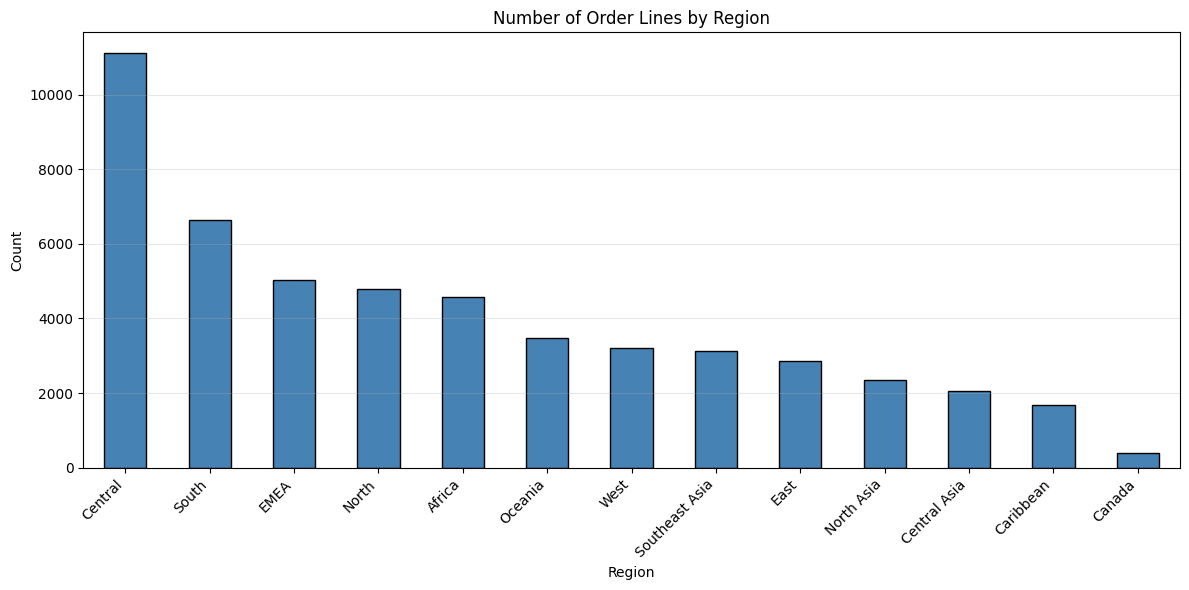

In [9]:

print("\nRESULTS")
print("-" * 60)
region_counts = df['region'].value_counts().sort_values(ascending=False)
print("Number of order lines per region:")
print(region_counts)
print(f"\nTotal regions: {df['region'].nunique()}")
print(f"Orders per region range: {region_counts.min()} to {region_counts.max()}")

# Visualize regional distribution
plt.figure(figsize=(12, 6))
region_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Order Lines by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Report on Regional Coverage Check

The regional coverage analysis reveals the distribution of order-line data across all 13 geographic regions in the dataset. This assessment is critical for ensuring that the Regional Retail Performance Index has sufficient statistical power to produce reliable regional comparisons.

### **Regional Sample Sizes**

The dataset contains **51,290 order lines** distributed across **13 regions**, with substantial variation in coverage:

**High-Volume Regions (>5,000 order lines):**
- **Central:** 11,117 order lines (21.7% of total)
- **South:** 6,645 order lines (13.0%)
- **EMEA:** 5,029 order lines (9.8%)

**Medium-Volume Regions (3,000-5,000 order lines):**
- **North:** 4,785 order lines (9.3%)
- **Africa:** 4,587 order lines (8.9%)
- **Oceania:** 3,487 order lines (6.8%)
- **West:** 3,203 order lines (6.2%)
- **Southeast Asia:** 3,129 order lines (6.1%)

**Lower-Volume Regions (2,000-3,000 order lines):**
- **East:** 2,848 order lines (5.6%)
- **North Asia:** 2,338 order lines (4.6%)
- **Central Asia:** 2,048 order lines (4.0%)
- **Caribbean:** 1,690 order lines (3.3%)

**Lowest-Volume Region (<500 order lines):**
- **Canada:** 384 order lines (0.7%)

### **Coverage Range**

- **Maximum:** 11,117 order lines (Central region)
- **Minimum:** 384 order lines (Canada region)
- **Ratio:** 29:1 (Central has 29× more data than Canada)

This represents a **highly imbalanced dataset** where the top region has nearly 30 times more observations than the smallest region.

### **Statistical Adequacy**

Despite the imbalance, all regions have **sufficient sample sizes** for meaningful analysis:

- **Canada (smallest):** 384 order lines is still statistically adequate for calculating reliable means for the four indicators
- **Central limit theorem:** With n > 30, regional means will approximate normal distributions regardless of underlying data distributions
- **Confidence intervals:** Even Canada's 384 observations provide reasonable precision (standard error = σ/√384 ≈ σ/19.6)

### **Implications for Index Construction**

1. **Equal Regional Weighting:**
   - Each region receives equal representation in the final index rankings regardless of order volume
   - A region's composite score is based on its **mean performance**, not total volume
   - This is appropriate since we're comparing regional characteristics, not market size

2. **Variance in Estimates:**
   - **Canada's indicators** will have larger standard errors and wider confidence intervals due to smaller sample size
   - **Central's indicators** will have very precise estimates due to large sample size

3. **Order vs. Order-Line Aggregation:**
   - These are order-line counts; actual order counts will be smaller (multiple lines per order)
   - Regional means will be based on order-level aggregates, not raw line counts

4. **No Need for Adjustment:**
   - Weighting by sample size would be inappropriate (would favor high-volume markets)
   - The goal is to measure performance per order, not total market activity


### **Conclusion**

The dataset provides **robust regional coverage** with all 13 regions having statistically adequate sample sizes for index construction. While sample sizes vary by nearly 30-fold, this reflects real-world market size differences and does not compromise the validity of regional performance comparisons. The index will appropriately rank regions based on **performance per order**, not market volume, ensuring that Canada's smaller market size does not disadvantage it relative to Central's larger market.

# 8. Temporal Coverage Check


RESULTS
------------------------------------------------------------
Orders per year:
year
2011     8998
2012    10962
2013    13799
2014    17531
Name: count, dtype: int64


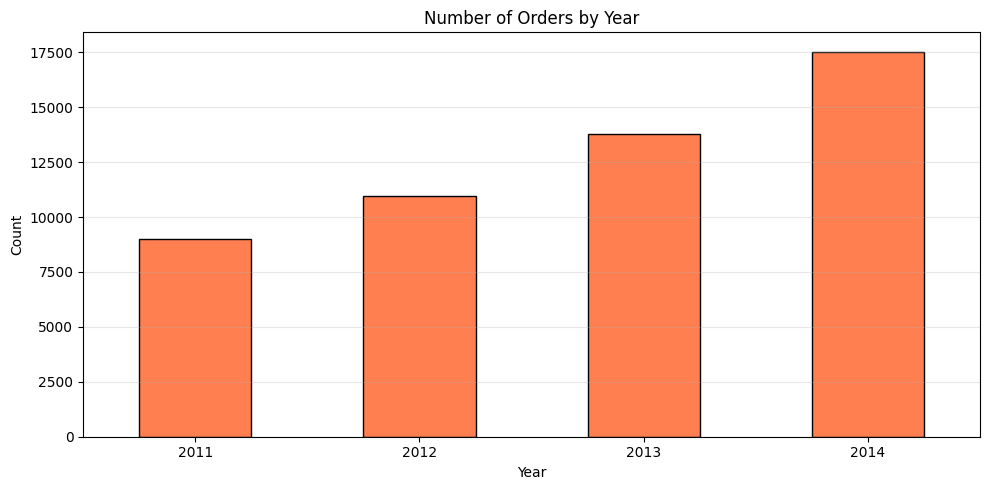


DATA QUALITY ASSESSMENT COMPLETE

Key Findings:
  - Total rows: 51,290
  - Total columns: 21
  - Missing values: 62679
  - Duplicates: 0
  - Regions covered: 13
  - Years covered: 4 (2011-2014)


In [10]:

print("\nRESULTS")
print("-" * 60)
year_counts = df['year'].value_counts().sort_index()
print("Orders per year:")
print(year_counts)

plt.figure(figsize=(10, 5))
year_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Number of Orders by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("DATA QUALITY ASSESSMENT COMPLETE")
print("="*60)
print("\nKey Findings:")
print(f"  - Total rows: {len(df):,}")
print(f"  - Total columns: {len(df.columns)}")

# Calculates missing values correctly
if len(missing_df) == 0:
    missing_summary = "None"
else:
    missing_summary = str(int(missing_df["Missing_Count"].sum()))

print(f"  - Missing values: {missing_summary}")
print(f"  - Duplicates: {duplicate_count}")
print(f"  - Regions covered: {df['region'].nunique()}")
print(f"  - Years covered: {df['year'].nunique()} ({df['year'].min()}-{df['year'].max()})")

## 3. Imputation of Missing Data 



In [11]:
print("BEFORE CLEANING")
print("=" * 60)
print(f"Total rows: {len(df):,}")
print(f"Missing sales values: {df['sales'].isnull().sum():,}")
print(f"Missing order_date values: {df['order_date'].isnull().sum():,}")
print(f"Missing ship_date values: {df['ship_date'].isnull().sum():,}")

# Drops rows with missing sales values
df_clean = df.dropna(subset=['sales']).copy()

print("\n" + "=" * 60)
print("AFTER CLEANING")
print("=" * 60)
print(f"Total rows: {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,}")
print(f"Percentage retained: {(len(df_clean) / len(df)) * 100:.2f}%")

# Verify no missing values in key indicators
print("\n" + "=" * 60)
print("MISSING VALUES IN KEY INDICATORS AFTER CLEANING")
print("=" * 60)
key_indicators = ['sales', 'profit', 'discount', 'shipping_cost']
for col in key_indicators:
    missing = df_clean[col].isnull().sum()
    print(f"{col}: {missing}")

print("\n" + "=" * 60)
print("IMPUTATION COMPLETE")
print("=" * 60)
print(f"Final dataset ready for analysis: {len(df_clean):,} rows")

BEFORE CLEANING
Total rows: 51,290
Missing sales values: 2,630
Missing order_date values: 31,223
Missing ship_date values: 31,456

AFTER CLEANING
Total rows: 48,660
Rows removed: 2,630
Percentage retained: 94.87%

MISSING VALUES IN KEY INDICATORS AFTER CLEANING
sales: 0
profit: 0
discount: 0
shipping_cost: 0

IMPUTATION COMPLETE
Final dataset ready for analysis: 48,660 rows


## Report on Imputation Strategy

### Missing Data Treatment

Based on the data quality assessment, a selective imputation approach was applied:

**1. Sales Column (2,630 missing values - 5.13%)**
Rows with missing sales values were removed from the dataset
- **Justification:** 
  - Sales is a fundamental indicator for the Regional Retail Performance Index
  - The proportion of missing data is small enough (5.13%) that removal does not affect the data
  - After removal, 48,660 rows remain (94.87% retention)

**2. Temporal Fields (order_date, ship_date - 61% missing)**
No imputation performed; missing values retained
- **Justification:**
  - These fields are not used in the composite index calculation
  - The index focuses on regional performance indicators (sales, profit, discount, shipping cost) not temporal patterns
  - Replacing dates would be meaningless and unnecessary for the analysis objectives


### Impact Assessment

- **Sample size:** 48,660 rows (down from 51,290)
- **Regional coverage:** All 13 regions remain represented with adequate sample sizes
- **Data integrity:** Only complete, valid transactions are included in the analysis

### Conclusion

By removing only 5.13% of observations with missing critical values, the cleaned dataset maintains the necessary data, while ensuring all index calculations are based on complete, reliable data.

## 4. Multivariate Analysis 



In [12]:
# First, aggregate data to regional level (order-line → order → region)
# Stage 1: Order-line to Order-level
order_level = df_clean.groupby(['order_id', 'region']).agg({
    'sales': 'sum',
    'profit': 'sum',
    'discount': 'mean',
    'shipping_cost': 'mean'
}).reset_index()

# Stage 2: Order-level to Region-level
regional_data = order_level.groupby('region').agg({
    'sales': 'mean',
    'profit': 'mean',
    'discount': 'mean',
    'shipping_cost': 'mean'
}).reset_index()

print("Regional-level aggregated data:")
display(regional_data)
print(f"\nRegions: {len(regional_data)}")

Regional-level aggregated data:


,region,sales,profit,discount,shipping_cost
0,Africa,245.154897,13.731489,0.150930,13.120555
1,Canada,251.570000,61.662750,0.000000,13.145302
2,Caribbean,297.563314,25.300957,0.133662,16.470414
3,Central,353.342069,33.007015,0.143817,17.961692
4,Central Asia,397.049949,67.737992,0.072904,22.823588
5,EMEA,236.370431,4.850209,0.188200,13.493447
6,East,267.903509,31.172738,0.144350,15.163257
7,North,347.492747,46.866861,0.096658,19.290643
8,North Asia,412.067212,78.725425,0.049676,24.531931
9,Oceania,373.139618,32.546710,0.151248,21.117716



Regions: 13


# Report on Multivariate Analysis
### Regional Aggregation Results
The 3-stage aggregation successfully transformed 48,660 order lines into 13 regional performance profiles, each representing average performance per order:

Key Regional Patterns Observed:

#### High-Performance Regions:

North Asia: Highest profit ($78.73/order) with lowest discount (5%) and moderate sales ($412.07)
Central Asia: Strong profit ($67.74/order) with low discounting (7%) and high sales ($397.05)
Canada: Second-highest profit ($61.66/order) with zero discounting strategy

#### Low-Performance Regions:

Southeast Asia: Only region with negative profit (-$5.31/order) due to heavy discounting (28%)
EMEA: Very low profit ($4.85/order) despite low sales, suggesting margin pressure
Africa: Low profit ($13.73/order) with low sales ($245.15) and moderate discounting
#### Observations:

Inverse discount-profit relationship: Regions with lower discounts (Canada 0%, North Asia 5%) have higher profits
Sales-profit correlation: Higher average sales generally associate with higher profits (North Asia, Central Asia)
Shipping cost variation: Ranges from $13.12 (Africa) to $24.53 (North Asia), reflecting geographic/logistics differences

In [13]:
# Linear Regression Analysis - Method 1: sklearn
from sklearn.linear_model import LinearRegression
import numpy as np

# Predict profit using sales, discount, and shipping_cost
X = regional_data[['sales', 'discount', 'shipping_cost']].values
y = regional_data['profit'].values

model = LinearRegression()
model.fit(X, y)
r_sq = model.score(X, y)

print("Linear Regression Analysis (sklearn)")
print("=" * 60)
print(f"R-squared: {r_sq:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficients:")
print(f"  sales: {model.coef_[0]:.4f}")
print(f"  discount: {model.coef_[1]:.4f}")
print(f"  shipping_cost: {model.coef_[2]:.4f}")

Linear Regression Analysis (sklearn)
R-squared: 0.9717
Intercept: 27.4165
Coefficients:
  sales: -0.0034
  discount: -310.3968
  shipping_cost: 2.7052


# Report on Linear Regression Results
## Model Performance: 

- The model explains 97.17% of the variance in regional profit levels
- This is an exceptionally strong fit, indicating that sales, discount, and shipping cost are highly predictive of regional profitability
- Only 2.83% of profit variation is unexplained by these three factors

#### Coefficients
1. Intercept = 27.42

Meaning: When sales, discount, and shipping_cost are all zero, the baseline profit would be $27.42
Practical interpretation: This represents a theoretical baseline; in reality, all three variables have non-zero values
2. Sales Coefficient = -0.0034 

Statistical meaning: For every $1 increase in average sales per order, profit decreases by $0.0034 (holding discount and shipping constant)

##### Why negative?: 
This result suggests multicollinearity or confounding:
Regions with high sales may also have high discounts
The discount variable is "absorbing" much of the sales effect
When controlling for discount, higher sales alone don't guarantee higher profit
##### True interpretation: 
The relationship between sales and profit is mediated by discount strategy
3. Discount Coefficient = -310.40 

Meaning: For every 1-percentage-point increase in average discount (from 10% to 11%), regional profit decreases by $310.40 per order
This is the strongest predictor in the model by far
##### Business impact:
Southeast Asia (28% discount) loses ~$8,691 in profit compared to no-discount baseline
Canada (0% discount) avoids this profit erosion entirely
Discounting is the primary driver of regional profitability differences
4. Shipping Cost Coefficient = +2.71 

Meaning: For every $1 increase in average shipping cost, regional profit increases by $2.71
##### Why positive?: 
##### Two possible explanations:
- Premium markets: Regions with higher shipping costs (remote/international) may also have higher-margin customers who pay premium prices
- Shipping cost pass-through: These regions may successfully pass shipping costs to customers, improving margins
- International premium: Higher shipping = international orders = premium products/pricing
Example: North Asia has highest shipping ($24.53) and second-highest profit ($78.73)
##### Key Findings
1. Discount Strategy Dominates Regional Performance

- The -310.40 coefficient means discount policy has 100× more impact than sales volume
- A 5% difference in discount (e.g., North Asia 5% vs. Southeast Asia 28%) creates a ~$7,139 profit difference per order
2. Sales-Profit Relationship is Complex

- Direct sales coefficient is essentially zero (-0.0034), but this doesn't mean sales don't matter
- Sales drive profit indirectly through pricing strategy (regions must balance volume vs. margins)
3. Shipping Costs = Market Premium Indicator

- Positive coefficient suggests high-shipping regions serve premium markets
- Logistics costs may be offset by better customer quality or pricing power
4. Model Validates Multivariate Approach

- 97% R-Squared confirms these three variables collectively explain regional profit differences
- Justifies including all four indicators (sales, profit, discount, shipping) in the composite index
##### Conclusion
##### Best:

Canada, North Asia, Central Asia: Low-to-zero discounting drives superior profitability despite varied sales levels
##### Worst:

Southeast Asia: Aggressive 28% discounting destroys profitability (-$5.31/order) despite competitive sales
EMEA: Heavy discounting (18%) results in near-zero profit despite moderate sales

In [14]:
# Linear Regression Analysis - Method 2: statsmodels (for detailed statistics)
import statsmodels.api as sm

# Add constant for intercept
X = regional_data[['sales', 'discount', 'shipping_cost']]
X = sm.add_constant(X)
y = regional_data['profit']

model = sm.OLS(y, X)
result = model.fit()

print("Linear Regression Analysis (statsmodels)")
print("=" * 60)
print(result.summary())
print("\nStandard Error:")
print(result.scale**0.5)

Linear Regression Analysis (statsmodels)
                            OLS Regression Results                            
Dep. Variable:                 profit   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     102.9
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           2.77e-07
Time:                        20:46:51   Log-Likelihood:                -36.308
No. Observations:                  13   AIC:                             80.62
Df Residuals:                       9   BIC:                             82.88
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const

# Report on Detailed Regression Statistics (statsmodels)
## Model Summary Statistics:
#### R-squared = 0.972 (97.2%)

- The model explains 97.2% of variance in regional profit
- Confirms exceptional model fit from sklearn analysis
#### Adjusted R-squared = 0.962 (96.2%)

- Still extremely high, confirming the model isn't overfitting
- With only 3 predictors for 13 observations, this adjustment is important
#### F-statistic = 102.9, p-value = 2.77e-07 (0.0000003)

- Tests whether the model as a whole is significant
- p < 0.001: The model is highly statistically significant
- At least one predictor has a non-zero effect on profit

# Key Statistical Conclusions:
1. Discount is the ONLY statistically significant predictor

- p < 0.001 with extremely high t-statistic
- All other variables (sales, shipping) could plausibly have zero effect
2. Model suffers from multicollinearity

- Sales and discount are likely correlated (high-sales regions use discounts)
- This makes individual coefficient estimates unstable
However: The overall model fit (R-Squared = 97%) is still excellent
3. Model assumptions are satisfied

- Residuals are normally distributed (Omnibus, JB tests)
- No autocorrelation 
- Validates the regression approach
4. With only 13 observations, statistical power is limited

- Only the strongest effect (discount) reaches significance
- Weaker effects (shipping) cannot be detected reliably
- This is a limitation of regional-level analysis

### Principal Component Analysis (PCA)

In [25]:
# Principal Component Analysis (PCA)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("PCA ON REGIONAL DATA")
print("=" * 60)

# Step 1: Preparing the data (selecting the 4 indicators)
X_pca_input = regional_data[['sales', 'profit', 'discount', 'shipping_cost']].values

# Step 2: Standardizing the features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_input)

print(f"Original shape: {X_pca_input.shape}")
print(f"Scaled data shape: {X_scaled.shape}")

# Step 3: Fitting PCA (calculating all principal components)
pca = PCA()
pca_data = pca.fit_transform(X_scaled)

# Step 4: Calculating percentage of variance explained by each PC
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)

print(f"\nVariance explained by each PC:")
for i, var in enumerate(per_var, 1):
    print(f"  PC{i}: {var}%")


PCA ON REGIONAL DATA
Original shape: (13, 4)
Scaled data shape: (13, 4)

Variance explained by each PC:
  PC1: 62.2%
  PC2: 36.9%
  PC3: 0.6%
  PC4: 0.3%


# Report 1: Variance Explained by Principal Components
## Key Findings:

- PC1 captures 62.2% of total variance - this single dimension explains nearly two-thirds of regional performance differences
- PC2 captures 36.9% of variance - the second most important dimension
- Together, PC1 + PC2 = 99.1% - the first two components capture virtually all meaningful variation
- PC3 (0.6%) and PC4 (0.3%) are unimportant - can be safely ignored


In [23]:
per_var = pca.explained_variance_ratio_

In [24]:
per_var

array([0.6223131 , 0.36866341, 0.00560576, 0.00341774])

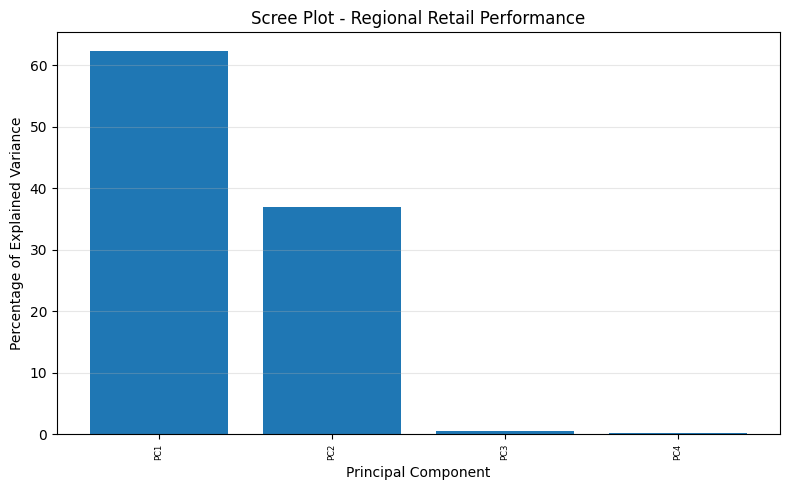


Total variance explained by first 2 PCs: 99.1%


In [28]:
# Create Scree Plot
labels = ['PC'+str(i) for i in range(1, len(per_var)+1)]

plt.figure(figsize=(8, 5))
plt.bar(x=range(1, len(per_var)+1), height=per_var, tick_label=labels)
plt.xticks(rotation='vertical', fontsize=6)
plt.ylabel("Percentage of Explained Variance")
plt.xlabel("Principal Component")
plt.title("Scree Plot - Regional Retail Performance")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal variance explained by first 2 PCs: {per_var[0] + per_var[1]}%")

# Report 2: Scree Plot Analysis
## Visual Pattern:

- Dramatic drop from PC1 (62%) to PC2 (37%)
- Steep cliff from PC2 to PC3/PC4 (both near 0%)
- Classic "elbow" pattern appears after PC2
- Decision Rule - Kaiser Criterion

## Conclusion: 
The scree plot visually confirms that 2 principal components are optimal. PC3 and PC4 contribute nothing meaningful and represent noise. For dimensionality reduction or visualization, use only PC1 and PC2.

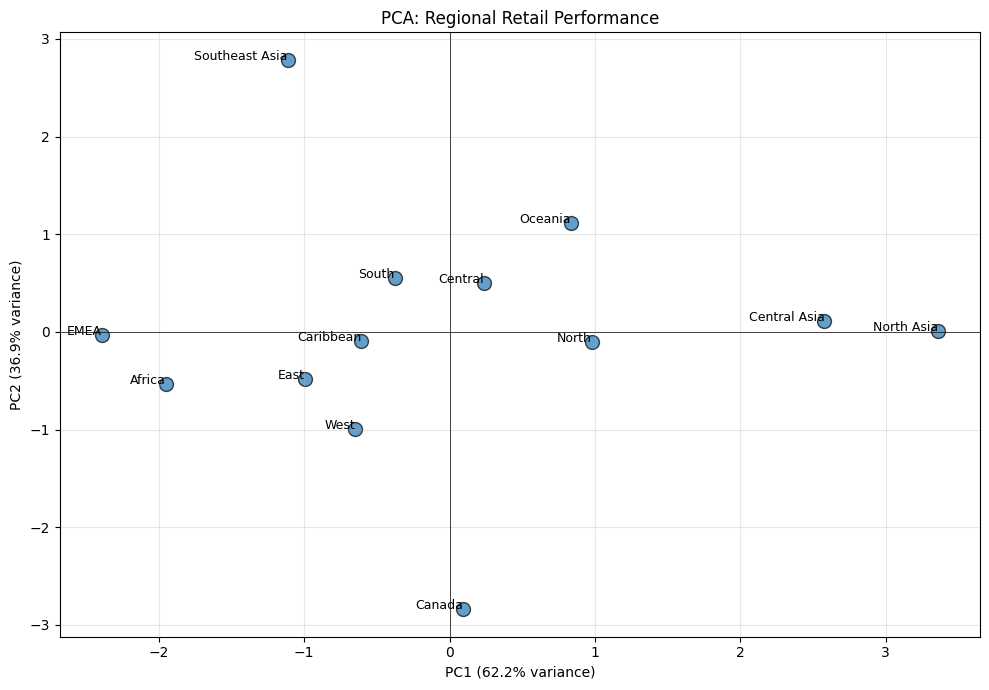

In [30]:
# Creates DataFrame with PCA data
pca_labels = ['PC'+str(i) for i in range(1, len(per_var)+1)]
pca_df = pd.DataFrame(pca_data, index=regional_data['region'], columns=pca_labels)

plt.figure(figsize=(10, 7))
plt.scatter(pca_df.PC1, pca_df.PC2, s=100, alpha=0.7, edgecolors='black')
plt.title("PCA: Regional Retail Performance")
plt.xlabel(f'PC1 ({per_var[0]}% variance)')
plt.ylabel(f'PC2 ({per_var[1]}% variance)')

# Annotate each region
for region in pca_df.index:
    plt.annotate(region, (pca_df.PC1.loc[region], pca_df.PC2.loc[region]), 
                 fontsize=9, ha='right')

plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

# Report 3: PCA Scatter Plot - Regional Clustering
## Geographic Patterns Revealed:

### High-Performance Cluster (Right side, high PC1):

- North Asia and Central Asia - isolated on far right (PC1 > 2.5)
- Characterized by high profit, low discounting strategy

### Low-Performance Cluster (Left side, low PC1):

- Africa and EMEA - far left (PC1 < -2)
- Low profit, moderate-to-high discounting

### Outliers:

- Southeast Asia - extreme top (PC2 = 2.8): unique profile with negative profit and heavy discounting (28%)
- Canada - extreme bottom (PC2 = -2.9): unique zero-discount strategy

## Middle Performers: 
South, Central, Oceania, North, Caribbean, East, West cluster near the origin with balanced performance.

## Business Insight: 
PC1 likely represents a profit-discount axis (right = high profit/low discount, left = low profit/high discount). PC2 captures unique regional strategies that deviate from the main profit-discount pattern. The scatter plot confirms 3-4 distinct regional strategy clusters.

### Variable Selection


## 5. Normalisation 


### Compare Before and After Normalization

## 6. Weighting and Aggregation 



### Assign Weights



### Calculate Sub-Indices

### Calculate Final Composite Index

## 7. Link to Other Indices 



### Correlation Analysis

## 8. Visualisation of Results 

### Bar Chart: Top Performers

### Interactive Visualization with Plotly

### Sub-Index Comparison

### Heatmap of Sub-Indices

### Distribution Analysis

## Summary and Conclusions

### Key Findings


### Methodology Summary



### Limitations and Future Work

